# Convolutional Neural Networks

**Convolution Operation**   (Cross Correlation)

Input matrix $X$: $m\times n$

Kernel $K$: $k\times k$

Output matrix $Y$: $(m-k+1)\times (n-k+1)$


eg $X=[1,6,2;5,3,1;7,0,4], K = [1,2;-1,0]$.

$X\star K = [8,7;4,5]$

this is the mode = 'valid' convolution

the mode = 'full' has result

$X\star K $ will be a $(m+k-1)\times (n+k-1)$ matrix: its center will be the valid convolution.

**Convolution Layer:**

inputs: row of matrices, where $n=$ # input matrices is called the input depth

kernels: k1 k2 $\ldots $ kd, each a column of n matrices



We'll also have some biases, B1,$\ldots$,Bd.

Result is a sort of matrix product: $Y_1 = X_1\star K_{1n}+ \ldots +X_n\star K_{1n}+B_1$, etc
****


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate2d, convolve2d # scipy signal processing library

In [2]:
# example: computing convolutions in python

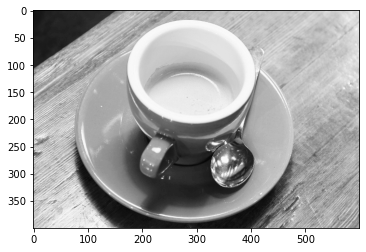

In [3]:
from skimage import data
image = data.coffee()[:,:,0]

plt.imshow(image,cmap='gray')

In [4]:


kernel_y = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])

kernel_y

array([[ 1,  0, -1],
       [ 2,  0, -2],
       [ 1,  0, -1]])

In [5]:
output = correlate2d(image, kernel_y, mode='valid')

output

array([[   4,    0,   -2, ...,   -8,  -19,   -3],
       [   3,    3,   -1, ...,  -10,  -14,   -7],
       [   1,    2,    1, ...,  -13,  -13,   -9],
       ...,
       [-107,  -31,    5, ...,  -22,   67,   42],
       [ -44,   26,   11, ...,   13,   63,   59],
       [  18,   22,   -3, ...,   43,   54,   55]])

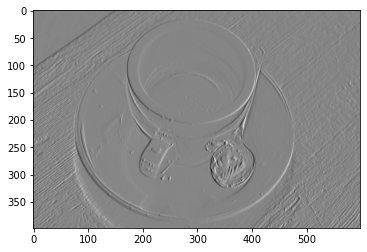

In [6]:
plt.imshow(output, cmap='gray')

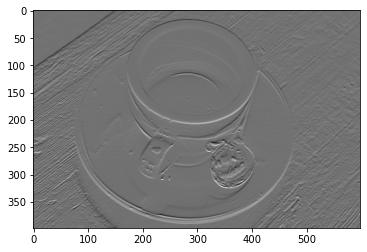

In [7]:
kernel_x = kernel_y.T


output2 = correlate2d(image, kernel_x, mode='valid')

plt.imshow(output2, cmap='gray')

In [8]:
class convolutional_layer:
    def __init__(self,input_shape, kernel_size, depth):
        # input shape = (input depth, width, height)
        input_depth, input_width, input_height = input_shape
    
        self.input_shape = input_shape
        self.input_depth =input_depth
    
        # depth = number of kernels
        self.depth = depth
    
        # output shape
        self.output_shape = (depth, height-kernel_size+1,input_width-kernel_size+1)
    
        # initialize kernels and biases
        self.kernels_shape = (depth, input_depth, kernel_size, kernel_size)
        self.weights = 0.1*np.random.randn(*self.kernels_shape)
        self.biases = np.zeros(self.output_shape)
        
        # initialize momentums and caches
        
        self.weigh_momentums = np.zeros(self.weights.shape)
        self.bias_momentums = np.zeros(self.biases.shape)
        self.weight_caches = np.zeros(self.weight.shape)
        self.bias_caches = np.zeros(self.biases.shape)
        
    def forward(self, inputs):
        # save inputs
        
        self.inputs = inputs
        self.outputs = self.biases.copy()
        for i in range(self.depth):
            for j in range(self.input_depth):
                self.outputs[i] += correlate2d(self.inputs[i],self.weights[i,j], mode='valid')
        
    def backward(self,dinputs):
        
        # initialize gradients
        self.dweights = np.zeros(self.kernels_shape)
        self.dinputs = np.zeros(self.input_shape)
        self.dbiases = dinputs.copy()
        
        for i in range(self.depth):
            for j in range(self.input_depth):
                self.dweights[i,j] = correlate2d(self.inputs[j], dinputs[i],mode='valid')
                self.dinputs[i,j] += convolve2d(dinputs[i],self.weights[i,j], mode = 'full')
                
        

SyntaxError: unexpected EOF while parsing (<ipython-input-8-b30a1eff17db>, line 29)

In [ ]:
import pandas as pd
url ='https://github.com/um-perez-alvaro/Data-Science-Theory/blob/master/Data/digits.csv'
data = pd.read_csv(url)
X = data.drop('label', axis=1).to_numpy()
X

In [ ]:
X = X.reshape(len(X),1,28,28)